# HEFEX III 2025

In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import pandas as pd

# Load HEFEXIII 1-minute flux datasets
hefex_root = Path("data/HEFEXIII")
smartflux_path = hefex_root / "fluxes_20Hz_smart_1min.nc"
standard_path = hefex_root / "fluxes_20Hz_1min.nc"

smartflux_ds = xr.open_dataset(smartflux_path)
standard_ds = xr.open_dataset(standard_path)

# Compute neutral aerodynamic roughness length z0 from MOST (no stability correction):
# z0 = z * exp(-(kappa * U) / u*)
def add_neutral_z0(ds, wind_var="meanU", ustar_var="ustar", height_coord="heights", kappa=0.41):
    if wind_var not in ds or ustar_var not in ds or height_coord not in ds.coords:
        print(f"Skipping z0 for dataset: missing one of {wind_var}, {ustar_var}, {height_coord}")
        return ds

    z = ds[height_coord]
    u = ds[wind_var]
    ustar = ds[ustar_var]

    valid = (ustar > 0) & np.isfinite(u) & np.isfinite(ustar)
    z0 = xr.where(valid, z * np.exp(-(kappa * u) / ustar), np.nan)
    z0.name = "z0"
    z0.attrs.update({
        "long_name": "Aerodynamic roughness length (neutral, no stability correction)",
        "units": "m",
        "formula": "z0 = z * exp(-(kappa * U) / u*)",
        "kappa": kappa,
    })
    return ds.assign(z0=z0)

smartflux_ds = add_neutral_z0(smartflux_ds)
standard_ds = add_neutral_z0(standard_ds)

smartflux_ds, standard_ds

print(standard_ds.data_vars)

Data variables:
    meanU    (time, heights) float64 1MB nan nan nan nan nan ... nan nan nan nan
    meanT    (time, heights) float32 587kB ...
    uu       (time, heights) float64 1MB ...
    vv       (time, heights) float64 1MB ...
    ww       (time, heights) float64 1MB ...
    uv       (time, heights) float64 1MB ...
    uw       (time, heights) float64 1MB ...
    vw       (time, heights) float64 1MB ...
    TT       (time, heights) float32 587kB ...
    uT       (time, heights) float64 1MB ...
    vT       (time, heights) float64 1MB ...
    wT       (time, heights) float64 1MB ...
    sdir     (time, heights) float64 1MB ...
    tke      (time, heights) float64 1MB ...
    uuu      (time, heights) float64 1MB ...
    vvv      (time, heights) float64 1MB ...
    www      (time, heights) float64 1MB ...
    TTT      (time, heights) float32 587kB ...
    uuv      (time, heights) float64 1MB ...
    uuw      (time, heights) float64 1MB ...
    uvw      (time, heights) float64 1MB .

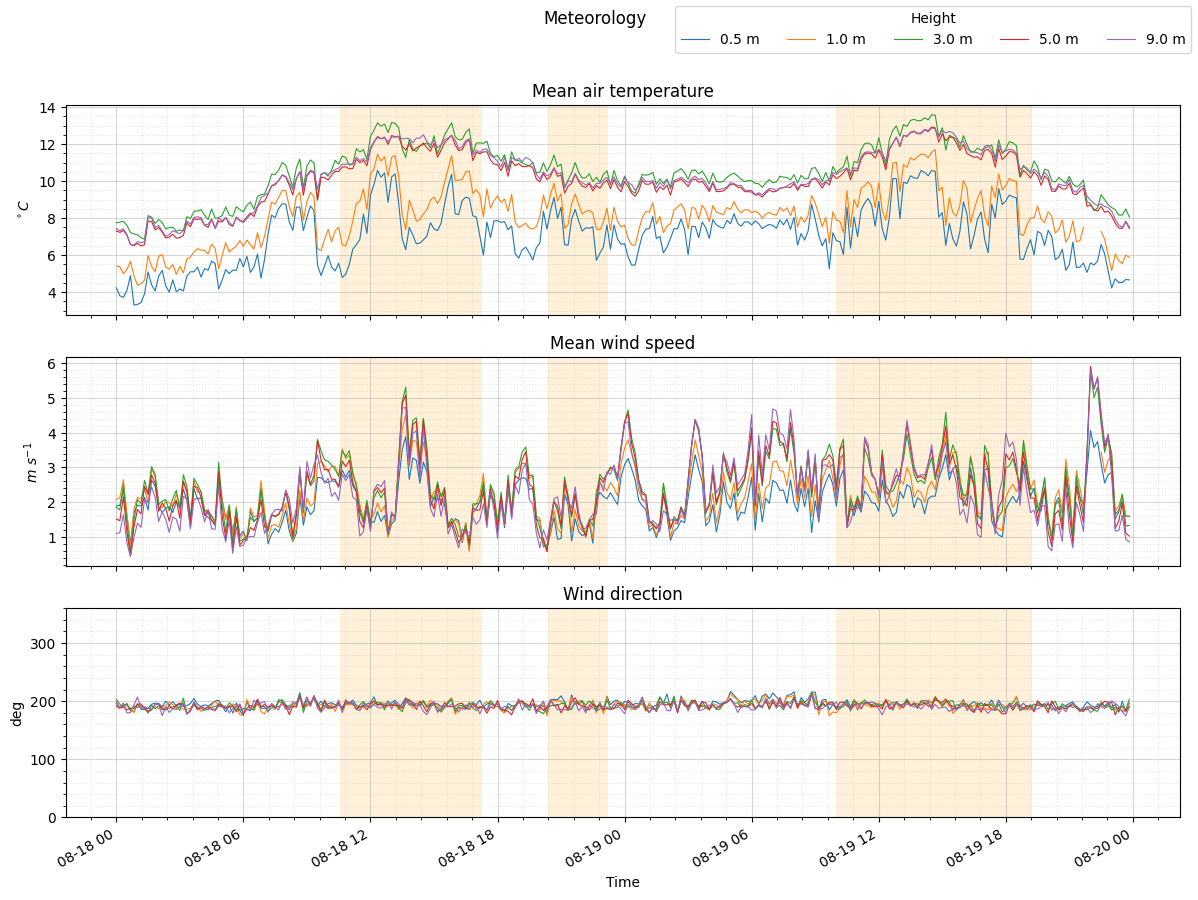

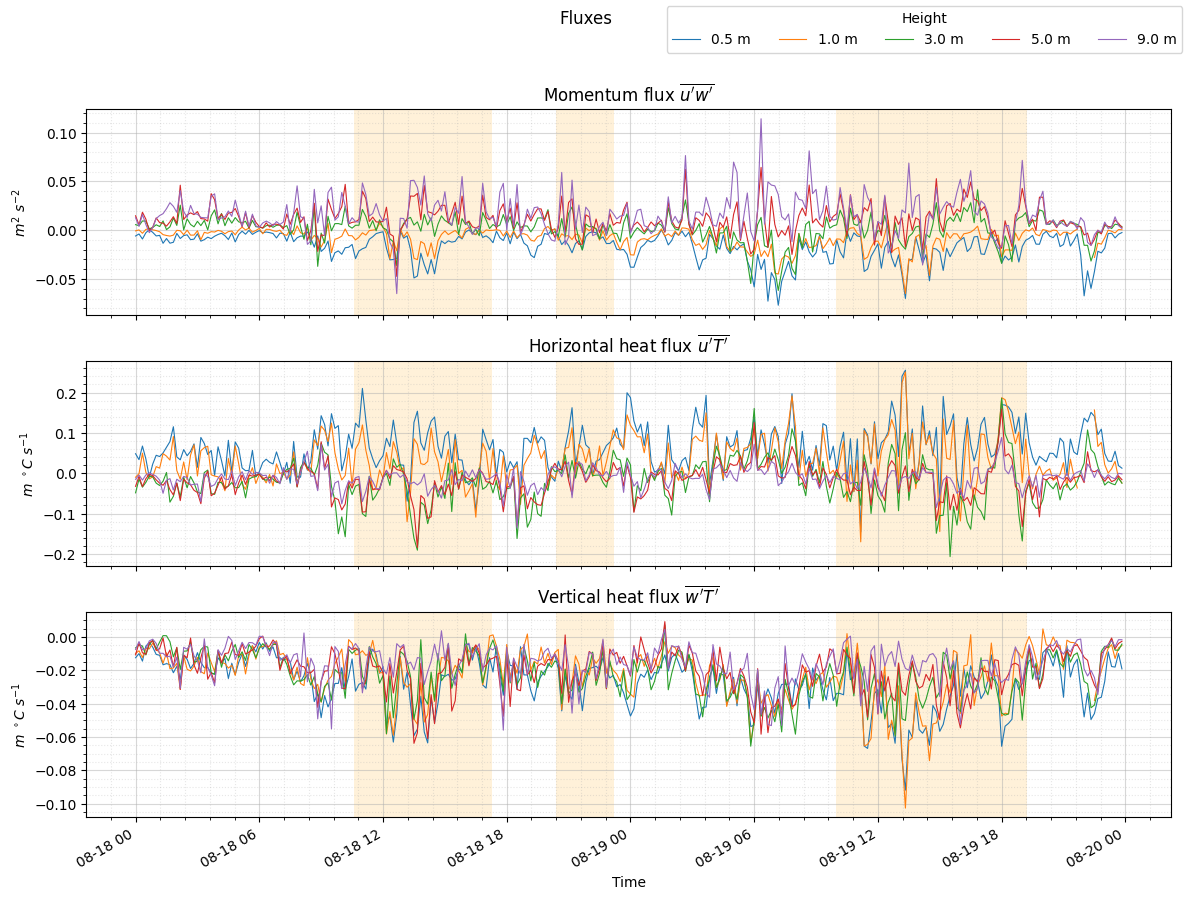

In [4]:
# Filter to Aug 18-19, 2025 and overlay all heights per variable (treat sensors the same)
subset_std = standard_ds.sel(time=slice("2025-08-18", "2025-08-19"))
subset_smart = smartflux_ds.sel(time=slice("2025-08-18", "2025-08-19"))

# Plot configuration
plot_linewidth = 0.8
plot_resample_interval = "10min"  # e.g. "5min", "10min", "30min", "1H"
if plot_resample_interval:
    subset_std = subset_std.resample(time=plot_resample_interval).mean()
    subset_smart = subset_smart.resample(time=plot_resample_interval).mean()

heights_std = subset_std.heights.values
heights_smart = subset_smart.heights.values if "heights" in subset_smart.coords else []
all_heights = sorted(set(heights_std.tolist() + heights_smart.tolist()))
highlight = [
    (pd.to_datetime('2025-08-18 10:35'), pd.to_datetime('2025-08-18 17:16')),
    (pd.to_datetime('2025-08-18 20:23'), pd.to_datetime('2025-08-18 23:12')),
    (pd.to_datetime('2025-08-19 09:58'), pd.to_datetime('2025-08-19 19:15')),
]

vars_panel1 = [
    ("meanT", "Mean air temperature", r"$^\circ C$"),
    ("meanU", "Mean wind speed", r"$m\ s^{-1}$"),
    ("sdir", "Wind direction", r"deg"),
]
vars_panel2 = [
    ("uw", r"Momentum flux $\overline{u'w'}$", r"$m^2\ s^{-2}$"),
    ("uT", r"Horizontal heat flux $\overline{u'T'}$", r"$m\ ^\circ C\ s^{-1}$"),
    ("wT", r"Vertical heat flux $\overline{w'T'}$", r"$m\ ^\circ C\ s^{-1}$"),
]

# Helper to plot a list of variables on stacked subplots

def plot_panel(var_list, title_prefix):
    fig, axes = plt.subplots(len(var_list), 1, figsize=(12, 9), sharex=True)
    if len(var_list) == 1:
        axes = [axes]
    for ax, (name, title, unit) in zip(axes, var_list):
        has_var = False
        for hval in all_heights:
            series = None
            if name in subset_std and hval in subset_std.heights.values:
                series = subset_std[name].sel(heights=hval).to_pandas()
            elif name in subset_smart and hval in subset_smart.heights.values:
                series = subset_smart[name].sel(heights=hval).to_pandas()
            if series is None:
                continue
            ax.plot(series.index, series.values, label=f"{float(hval)} m", linewidth=plot_linewidth)
            has_var = True
        if not has_var:
            ax.set_visible(False)
            continue
        if name == "sdir":
            ax.set_ylim(0, 360)
        for start, end in highlight:
            ax.axvspan(start, end, color='orange', alpha=0.15, lw=0)
        ax.set_title(title)
        ax.set_ylabel(unit)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.grid(True, which="major", alpha=0.5)
        ax.grid(True, which="minor", alpha=0.3, linestyle=":")
    axes[-1].set_xlabel("Time")
    fig.autofmt_xdate()
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Height", loc="upper right", ncol=len(all_heights))
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.suptitle(title_prefix, y=0.995)
    return fig

fig1 = plot_panel(vars_panel1, "Meteorology")
fig2 = plot_panel(vars_panel2, "Fluxes")


## Roughness calculation

In [ ]:
# Exact diagnostic: first and last 10 values of every variable (both datasets)
for ds_name, ds in [("standard_ds", standard_ds), ("smartflux_ds", smartflux_ds)]:
    print("\n" + "#" * 100)
    print(f"Dataset: {ds_name}")

    for var_name in ds.data_vars:
        da = ds[var_name]
        print("\n" + "=" * 100)
        print(f"Variable: {var_name}")

        # Flatten to a 1D sample index to print exactly 10 first and 10 last scalar values
        if "time" in da.dims and "heights" in da.dims:
            s = da.stack(sample=("time", "heights")).to_series()
        elif "time" in da.dims:
            s = da.to_series()
        else:
            s = da.to_series()

        first10 = s.head(10)
        last10 = s.tail(10)

        print("First 10 values:")
        print(first10.to_string())
        print("Last 10 values:")
        print(last10.to_string())


####################################################################################################
Dataset: standard_ds

Variable: meanU
First 10 values:
time                 heights
2025-08-06 13:37:00  0.5       NaN
                     3.0       NaN
                     5.0       NaN
                     9.0       NaN
2025-08-06 13:38:00  0.5       NaN
                     3.0       NaN
                     5.0       NaN
                     9.0       NaN
2025-08-06 13:39:00  0.5       NaN
                     3.0       NaN
Last 10 values:
time                 heights
2025-09-01 00:55:00  5.0        4.791994
                     9.0        4.789267
2025-09-01 00:56:00  0.5        3.405849
                     3.0        4.993517
                     5.0        5.041303
                     9.0        4.963638
2025-09-01 00:57:00  0.5             NaN
                     3.0             NaN
                     5.0             NaN
                     9.0             NaN

Variable

In [ ]:
# Compact missingness summary relative to meanU
mu_nan = standard_ds["meanU"].isnull()
n_mu_nan = int(mu_nan.sum().item())
rows = []
for v in standard_ds.data_vars:
    vn = standard_ds[v].isnull()
    both = int((vn & mu_nan).sum().item())
    frac = both / n_mu_nan if n_mu_nan else float("nan")
    rows.append((v, frac))

rows = sorted(rows, key=lambda x: x[1], reverse=True)
print(f"meanU NaN points: {n_mu_nan}")
print("Top 10 variables with highest P(var NaN | meanU NaN):")
for v, frac in rows[:10]:
    print(f"{v:8s} {frac:.3f}")
print("Bottom 10 variables with lowest P(var NaN | meanU NaN):")
for v, frac in rows[-10:]:
    print(f"{v:8s} {frac:.3f}")

meanU NaN points: 9584
Top 10 variables with highest P(var NaN | meanU NaN):
meanU    1.000
meanT    1.000
uu       1.000
vv       1.000
ww       1.000
uv       1.000
uw       1.000
vw       1.000
TT       1.000
uT       1.000
Bottom 10 variables with lowest P(var NaN | meanU NaN):
uTT      1.000
vTT      1.000
wTT      1.000
uuuu     1.000
vvvv     1.000
wwww     1.000
TTTT     1.000
ustar    1.000
H        1.000
z0       1.000
